In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

In [ ]:
# 1) Read CSV file
df=pd.read_csv('/content/riceClassification.csv')

In [ ]:
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
print(device)

cuda


In [ ]:
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
df.shape

(18185, 12)

In [ ]:
print(df['Class'].unique())

[1 0]


In [ ]:
print(df['Class'].value_counts())

Class
1    9985
0    8200
Name: count, dtype: int64


In [ ]:
origina_df=df.copy()

In [ ]:
# Normalization
original_df = df.copy()

for column in df.columns:
    if column not in ["id", "Class"]:
        df[column] = df[column] / df[column].abs().max()

In [ ]:
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1
1,2,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1
2,3,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1
3,4,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1
4,5,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1


In [ ]:
# Split DataSet
x = df.drop(["id", "Class"], axis=1).values
y= df["Class"].values

Split data to:
Training,
Testing,
Validation,

صار تقسيم الداتا
*   
80% تدريب Training
10% اختبار Testing
10% تحقق Validation
*   


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_test, x_val, y_test, y_val = train_test_split(
    x_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(x_val.shape)

(14548, 10)
(1818, 10)
(1819, 10)


هنا سوّينا Custom Dataset class في PyTorch.

يعني بدل ما نستخدم Dataset جاهزة مثل MNIST، سوّينا كلاس خاص بنا عشان PyTorch يعرف كيف يقرأ بياناتنا x و y.

In [ ]:
class dataset(Dataset):
  def __init__(self,x,y):
    self.x=torch.tensor(x,dtype=torch.float32)
    self.y=torch.tensor(y,dtype=torch.float32)

  def __len__(self):

    return len(self.x)

  def __getitem__(self, index):

     return self.x[index],self.y[index]

In [ ]:
train_data=dataset(x_train,y_train)
test_data=dataset(x_test,y_test)
val_data=dataset(x_val,y_val)

In [ ]:
train_dataloader=DataLoader(train_data,batch_size=32,shuffle=True)
test_dataloader=DataLoader(test_data,batch_size=32,shuffle=False)
val_dataloader=DataLoader(val_data,batch_size=32,shuffle=False)

In [ ]:
for batch_x, batch_y in train_dataloader:
    print(batch_x.shape)
    print(batch_y.shape)
    break

torch.Size([32, 10])
torch.Size([32])


In [ ]:
HIDDEN_NEURONS=10
input_size = x_train.shape[1]
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(input_size, HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x
model=MyModel().to(device)

In [ ]:
summary(model,(x.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
              ReLU-2                   [-1, 10]               0
            Linear-3                    [-1, 1]              11
           Sigmoid-4                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


BCEWithLogitsLoss
بدل BCELoss

In [ ]:
criterion=nn. BCELoss()
optimizer=Adam(model.parameters(),lr=1e-3)

Traing And Valdtion Loob

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

epochs = 10

for epoch in range(epochs):

    # =====================
    # Training
    # =====================
    model.train()

    total_loss_train = 0
    total_correct_train = 0
    total_samples_train = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        prediction = model(inputs).squeeze(1)
        batch_loss = criterion(prediction, labels)

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

        total_loss_train += batch_loss.item() * labels.size(0)

        predicted_classes = prediction.round()
        total_correct_train += (predicted_classes == labels).sum().item()
        total_samples_train += labels.size(0)

    avg_train_loss = total_loss_train / total_samples_train
    avg_train_acc = total_correct_train / total_samples_train


    # =====================
    # Validation
    # =====================
    model.eval()

    total_loss_val = 0
    total_correct_val = 0
    total_samples_val = 0

    with torch.no_grad():
        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item() * labels.size(0)

            predicted_classes = prediction.round()
            total_correct_val += (predicted_classes == labels).sum().item()
            total_samples_val += labels.size(0)

    avg_val_loss = total_loss_val / total_samples_val
    avg_val_acc = total_correct_val / total_samples_val


    # =====================
    # Save results
    # =====================
    total_loss_train_plot.append(avg_train_loss)
    total_loss_val_plot.append(avg_val_loss)
    total_acc_train_plot.append(avg_train_acc)
    total_acc_val_plot.append(avg_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Train Acc: {avg_train_acc:.4f}")
    print(f"Val Acc: {avg_val_acc:.4f}")
    print("-" * 30)

Epoch [1/10]
Train Loss: 0.6481
Val Loss: 0.5537
Train Acc: 0.7063
Val Acc: 0.9555
------------------------------
Epoch [2/10]
Train Loss: 0.4185
Val Loss: 0.2932
Train Acc: 0.9695
Val Acc: 0.9769
------------------------------
Epoch [3/10]
Train Loss: 0.2177
Val Loss: 0.1624
Train Acc: 0.9798
Val Acc: 0.9808
------------------------------
Epoch [4/10]
Train Loss: 0.1323
Val Loss: 0.1090
Train Acc: 0.9821
Val Acc: 0.9852
------------------------------
Epoch [5/10]
Train Loss: 0.0953
Val Loss: 0.0833
Train Acc: 0.9832
Val Acc: 0.9868
------------------------------
Epoch [6/10]
Train Loss: 0.0766
Val Loss: 0.0695
Train Acc: 0.9841
Val Acc: 0.9879
------------------------------
Epoch [7/10]
Train Loss: 0.0657
Val Loss: 0.0600
Train Acc: 0.9849
Val Acc: 0.9885
------------------------------
Epoch [8/10]
Train Loss: 0.0589
Val Loss: 0.0536
Train Acc: 0.9852
Val Acc: 0.9885
------------------------------
Epoch [9/10]
Train Loss: 0.0544
Val Loss: 0.0513
Train Acc: 0.9851
Val Acc: 0.9879
-----

Test Loob

In [ ]:
with torch.no_grad():
  total_loss_test=0
  total_acc_test=0
  for data in test_dataloader:
    inputs,labels=data
    inputs = inputs.to(device)
    labels = labels.to(device)

    prediction=model(inputs).squeeze(1)
    batch_loss_test=criterion(prediction,labels).item()

    total_loss_test+=batch_loss_test

    acc=(prediction.round()==labels).sum().item()
    total_acc_test+=acc

print(f'Test Loss: {total_loss_test/len(test_dataloader)}')
print(f'Test Acc: {total_acc_test/len(test_dataloader)}')

Test Loss: 0.04287757039919757
Test Acc: 31.614035087719298


In [ ]:
print(len(total_loss_train_plot))
print(len(total_loss_val_plot))
print(len(total_acc_train_plot))
print(len(total_acc_val_plot))

10
10
10
10


Vasulizatio part

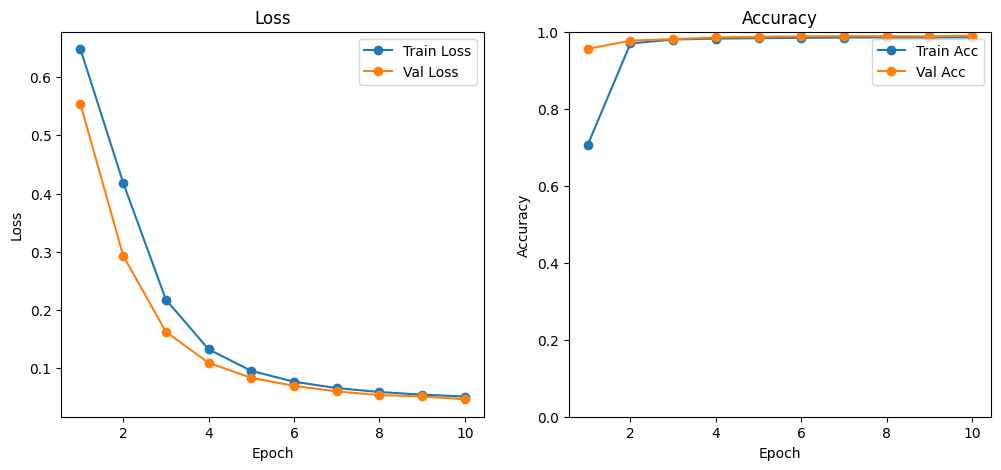

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(total_loss_train_plot) + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(epochs_range, total_loss_train_plot, marker='o', label='Train Loss')
axs[0].plot(epochs_range, total_loss_val_plot, marker='o', label='Val Loss')
axs[0].set_title("Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(epochs_range, total_acc_train_plot, marker='o', label='Train Acc')
axs[1].plot(epochs_range, total_acc_val_plot, marker='o', label='Val Acc')
axs[1].set_title("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].set_ylim(0, 1)
axs[1].legend()

plt.show()



In [ ]:
origina_df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [ ]:
id=2352/origina_df['Area'].abs().max()
area=2353/origina_df['Area'].abs().max()
MajorAxis=81/origina_df['MajorAxisLength'].abs().max()
MinorAxis=42/origina_df['MinorAxisLength'].abs().max()
Eccentricity=32/origina_df['Eccentricity'].abs().max()
ConvexArea=12/origina_df['ConvexArea'].abs().max()
EquivDiameter=33/origina_df['EquivDiameter'].abs().max()
Extent=98/origina_df['Extent'].abs().max()
Perimeter=927/origina_df['Perimeter'].abs().max()
AspectRation=677/origina_df['AspectRation'].abs().max()
Roundness=24/origina_df['Roundness'].abs().max()


My_prediction=model(torch.tensor([area,MajorAxis,MinorAxis,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,AspectRation,Roundness],dtype=torch.float32).to(device))

In [ ]:
My_prediction.item()

1.0